In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv(r"C:\Users\Asus\Downloads\corporate_ai_adoption_dataset.csv")

In [3]:
print(df.head())

   company_id            industry        country  year  ai_adoption_level  \
0  CORP-06613  Financial Services          China  2029             0.4987   
1  CORP-01597         Agriculture        Germany  2032             0.5213   
2  CORP-02938              Energy  United States  2024             0.6147   
3  CORP-05207              Retail        Germany  2021             0.4401   
4  CORP-07489          Technology  United States  2024             0.1918   

   ai_investment_usd  automation_rate  cost_savings  revenue_impact  \
0           11747237           0.4119       3519354         2751513   
1            1267219           0.4580        295244          304776   
2            8168951           0.5821       2472329         5170304   
3            1234261           0.2880        512061         -233448   
4            5000645           0.1906       2122064         2110644   

   productivity_gain  employee_ai_training_hours  ai_maturity_score  \
0             0.3924                   

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   company_id                  200000 non-null  object 
 1   industry                    200000 non-null  object 
 2   country                     200000 non-null  object 
 3   year                        200000 non-null  int64  
 4   ai_adoption_level           200000 non-null  float64
 5   ai_investment_usd           200000 non-null  int64  
 6   automation_rate             200000 non-null  float64
 7   cost_savings                200000 non-null  int64  
 8   revenue_impact              200000 non-null  int64  
 9   productivity_gain           200000 non-null  float64
 10  employee_ai_training_hours  200000 non-null  float64
 11  ai_maturity_score           200000 non-null  float64
 12  deployment_count            200000 non-null  int64  
dtypes: float64(5),

In [5]:
df.shape

(200000, 13)

In [6]:
df.describe()

,year,ai_adoption_level,ai_investment_usd,automation_rate,cost_savings,revenue_impact,productivity_gain,employee_ai_training_hours,ai_maturity_score,deployment_count
count,200000.000000,200000.000000,2.000000e+05,200000.000000,2.000000e+05,2.000000e+05,200000.000000,200000.000000,200000.000000,200000.000000
mean,2024.991490,0.527774,4.870558e+06,0.436723,2.128918e+06,2.591989e+06,0.395297,76.755334,6.271801,26.337350
std,6.051632,0.256470,3.679704e+06,0.217031,2.415689e+06,3.972751e+06,0.195623,40.046317,1.930643,11.853256
min,2015.000000,0.010000,4.788800e+04,0.000000,4.649000e+03,-1.437676e+07,-0.050000,1.000000,1.000000,3.000000
25%,2020.000000,0.334400,2.221252e+06,0.273500,5.993548e+05,5.339805e+05,0.249300,46.500000,4.730000,16.000000
50%,2025.000000,0.528600,3.991640e+06,0.428150,1.354826e+06,1.408779e+06,0.392600,75.400000,6.280000,25.000000
75%,2030.000000,0.725000,6.517931e+06,0.592000,2.745080e+06,3.132148e+06,0.539300,105.900000,7.830000,36.000000
max,2035.000000,1.000000,5.417034e+07,0.950000,4.433124e+07,1.294787e+08,0.940300,197.900000,10.000000,58.000000


In [7]:
# Check null values and handle them
df.isnull().sum()

company_id                    0
industry                      0
country                       0
year                          0
ai_adoption_level             0
ai_investment_usd             0
automation_rate               0
cost_savings                  0
revenue_impact                0
productivity_gain             0
employee_ai_training_hours    0
ai_maturity_score             0
deployment_count              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

# EDA

In [9]:
df['industry'].value_counts()

industry
Technology            35994
Manufacturing         29884
Financial Services    27927
Healthcare            24026
Retail                20048
Logistics             16021
Telecom               14128
Energy                14080
Agriculture            9934
Education              7958
Name: count, dtype: int64

In [10]:
df['country'].value_counts()

country
United States     50080
China             35906
Germany           16040
Japan             14125
United Kingdom    13989
India             13911
Canada            10114
France             9896
South Korea        8033
Brazil             7931
Australia          5960
Sweden             4057
Netherlands        4032
Singapore          3958
UAE                1968
Name: count, dtype: int64

In [11]:
df.groupby(df['industry'])['country'].apply(list)

industry
Agriculture           [Germany, United Kingdom, Australia, India, Ch...
Education             [United States, Japan, Singapore, United Kingd...
Energy                [United States, United States, Sweden, India, ...
Financial Services    [China, China, Germany, United States, Germany...
Healthcare            [Brazil, United States, China, Germany, China,...
Logistics             [United States, United States, Canada, France,...
Manufacturing         [Germany, United States, China, United States,...
Retail                [Germany, United Kingdom, France, United State...
Technology            [United States, China, China, United States, G...
Telecom               [South Korea, United States, United States, In...
Name: country, dtype: object

In [12]:
skewness = df['cost_savings'].skew()
print(skewness)

2.941821246770976


In [13]:
country_year_prod = (
    df.groupby(['country', 'year'])['productivity_gain']
      .mean()
      .reset_index()
)

best_year = country_year_prod.loc[
    country_year_prod.groupby('country')['productivity_gain'].idxmax()
]

print(best_year[['country', 'year', 'productivity_gain']])

            country  year  productivity_gain
20        Australia  2035           0.619062
41           Brazil  2035           0.592839
62           Canada  2035           0.628360
83            China  2035           0.635550
104          France  2035           0.622638
125         Germany  2035           0.634336
146           India  2035           0.614296
167           Japan  2035           0.629269
188     Netherlands  2035           0.622168
209       Singapore  2035           0.641122
230     South Korea  2035           0.627413
251          Sweden  2035           0.623690
272             UAE  2035           0.586120
293  United Kingdom  2035           0.647321
314   United States  2035           0.657573


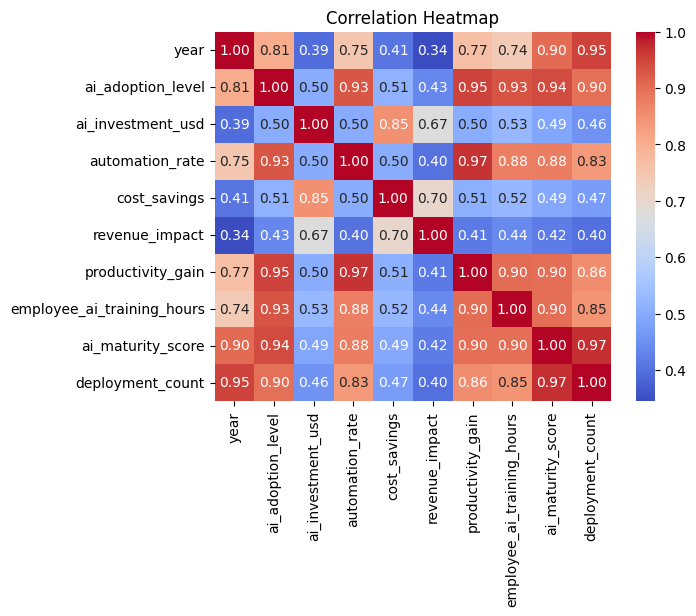

In [14]:
sns.heatmap(df.corr(numeric_only = True), cmap="coolwarm", annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   company_id                  200000 non-null  object 
 1   industry                    200000 non-null  object 
 2   country                     200000 non-null  object 
 3   year                        200000 non-null  int64  
 4   ai_adoption_level           200000 non-null  float64
 5   ai_investment_usd           200000 non-null  int64  
 6   automation_rate             200000 non-null  float64
 7   cost_savings                200000 non-null  int64  
 8   revenue_impact              200000 non-null  int64  
 9   productivity_gain           200000 non-null  float64
 10  employee_ai_training_hours  200000 non-null  float64
 11  ai_maturity_score           200000 non-null  float64
 12  deployment_count            200000 non-null  int64  
dtypes: float64(5),

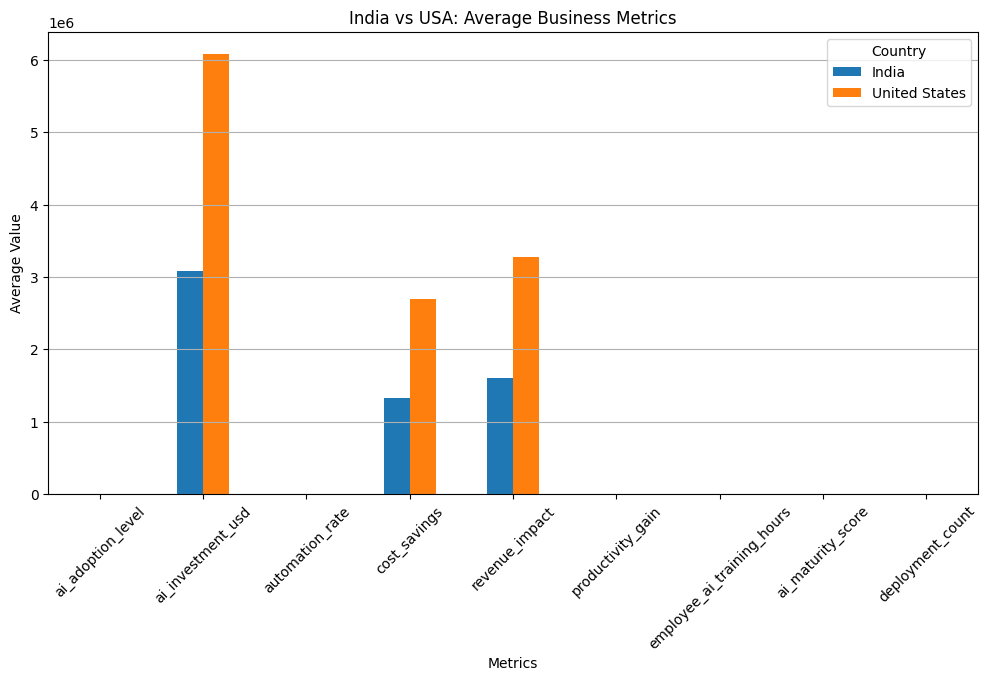

In [16]:
metrics = [
    'ai_adoption_level',
    'ai_investment_usd',
    'automation_rate',
    'cost_savings',
    'revenue_impact',
    'productivity_gain',
    'employee_ai_training_hours',
    'ai_maturity_score',
    'deployment_count'
]

comparison = df[df['country'].isin(['India', 'United States'])].groupby('country')[metrics].mean()

comparison.T.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('India vs USA: Average Business Metrics')
plt.xlabel('Metrics')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.legend(title='Country')
plt.grid(axis='y')
plt.show()

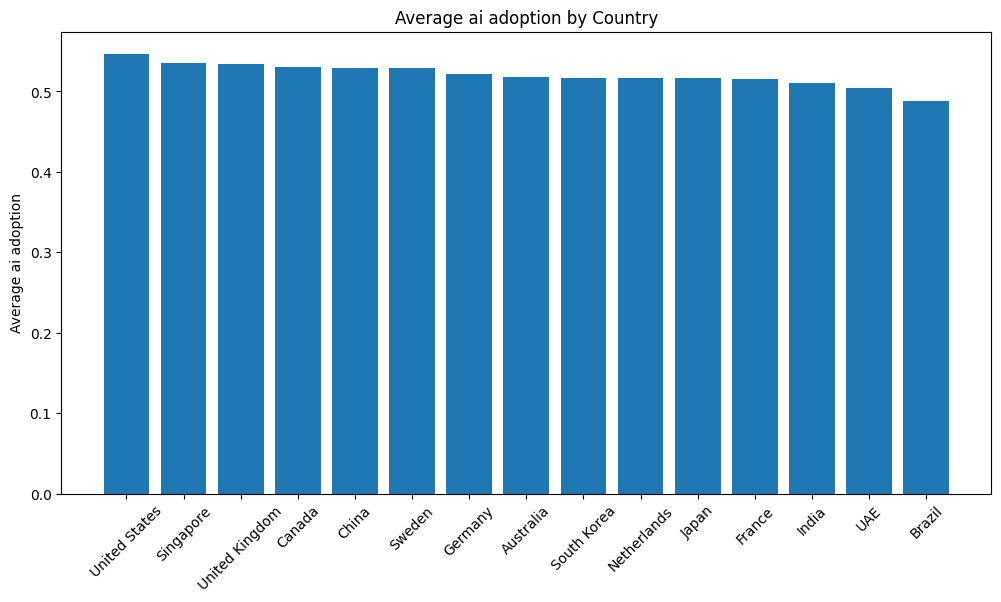

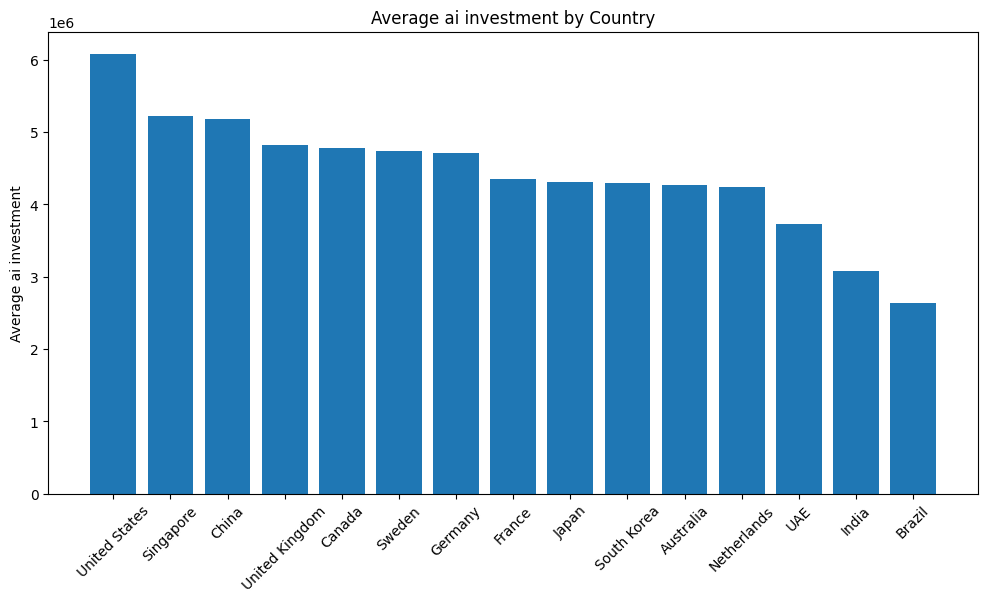

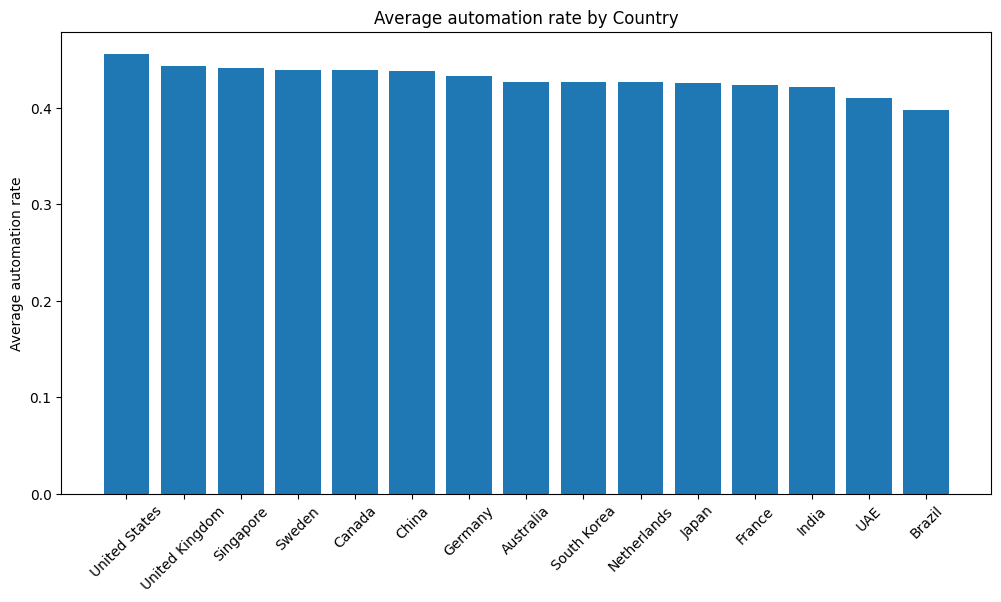

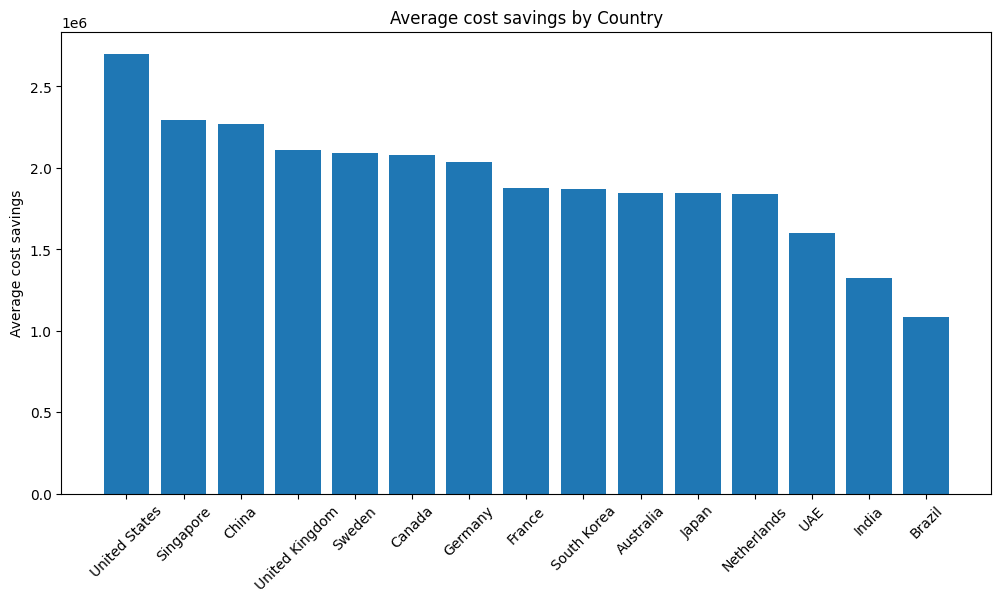

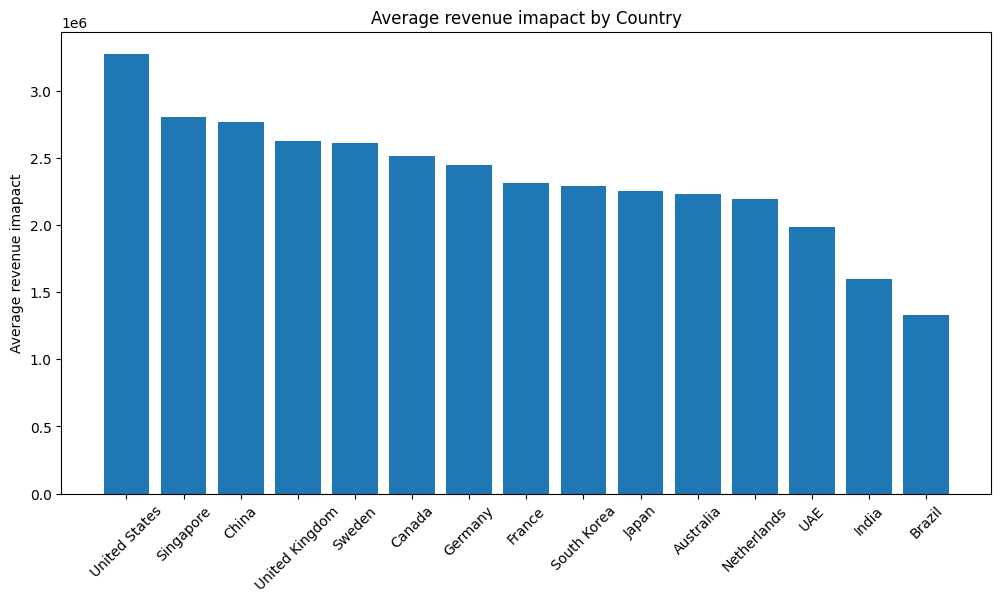

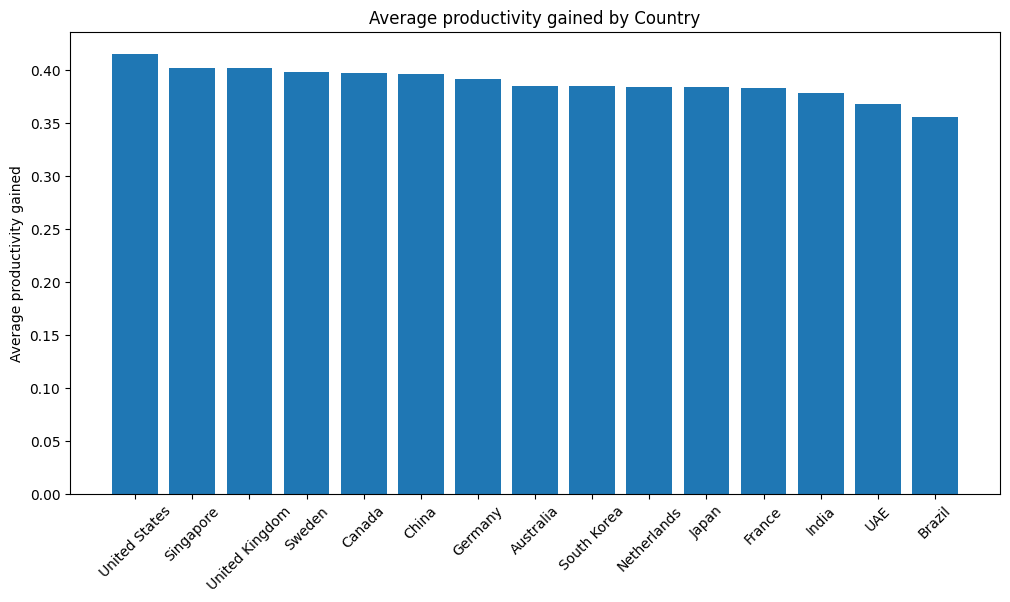

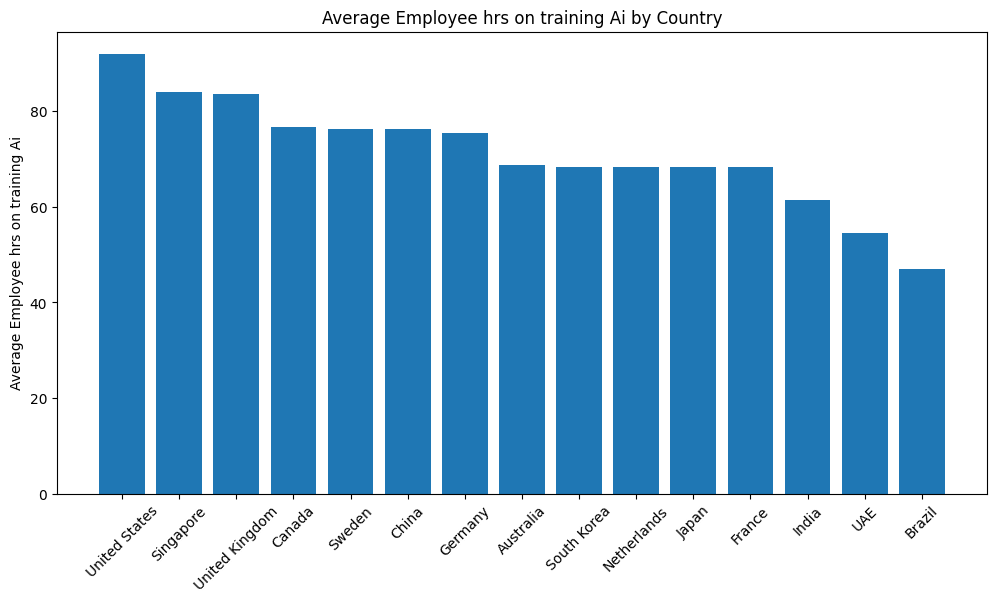

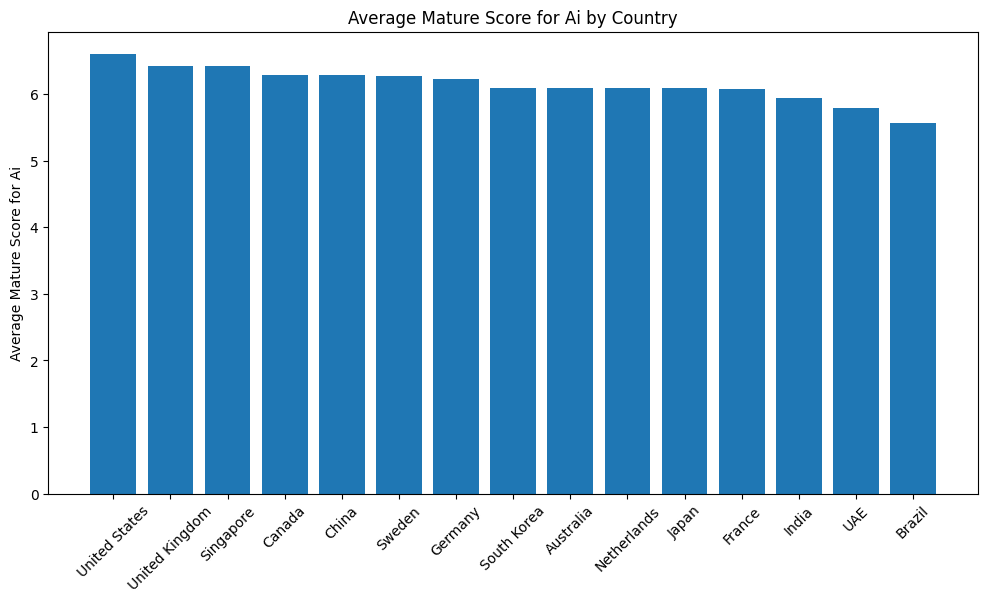

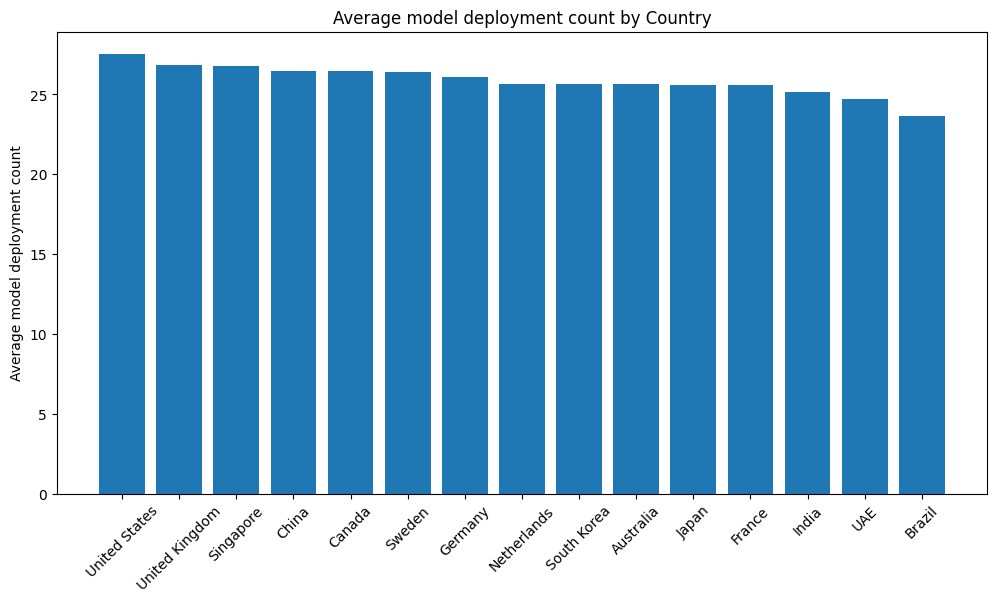

In [17]:
metrics = [
    'ai_adoption_level',
    'ai_investment_usd',
    'automation_rate',
    'cost_savings',
    'revenue_impact',
    'productivity_gain',
    'employee_ai_training_hours',
    'ai_maturity_score',
    'deployment_count'
]
y_label = [
    'Average ai adoption',
    'Average ai investment',
    'Average automation rate',
    'Average cost savings',
    'Average revenue imapact',
    'Average productivity gained',
    'Average Employee hrs on training Ai',
    'Average Mature Score for Ai',
    'Average model deployment count'
]

def plot_country_metric(df, metric, ylabel):
    data = df.groupby('country')[metric].mean().sort_values(ascending = False)
    
    plt.figure(figsize=(12,6))
    plt.bar(data.index, data.values)
    plt.xticks(rotation=45)
    plt.ylabel(ylabel)
    plt.title(f'{ylabel} by Country')
    plt.show()

for metric, label in zip(metrics, y_label):
    plot_country_metric(df, metric, label)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   company_id                  200000 non-null  object 
 1   industry                    200000 non-null  object 
 2   country                     200000 non-null  object 
 3   year                        200000 non-null  int64  
 4   ai_adoption_level           200000 non-null  float64
 5   ai_investment_usd           200000 non-null  int64  
 6   automation_rate             200000 non-null  float64
 7   cost_savings                200000 non-null  int64  
 8   revenue_impact              200000 non-null  int64  
 9   productivity_gain           200000 non-null  float64
 10  employee_ai_training_hours  200000 non-null  float64
 11  ai_maturity_score           200000 non-null  float64
 12  deployment_count            200000 non-null  int64  
dtypes: float64(5),

In [19]:
df.describe()

,year,ai_adoption_level,ai_investment_usd,automation_rate,cost_savings,revenue_impact,productivity_gain,employee_ai_training_hours,ai_maturity_score,deployment_count
count,200000.000000,200000.000000,2.000000e+05,200000.000000,2.000000e+05,2.000000e+05,200000.000000,200000.000000,200000.000000,200000.000000
mean,2024.991490,0.527774,4.870558e+06,0.436723,2.128918e+06,2.591989e+06,0.395297,76.755334,6.271801,26.337350
std,6.051632,0.256470,3.679704e+06,0.217031,2.415689e+06,3.972751e+06,0.195623,40.046317,1.930643,11.853256
min,2015.000000,0.010000,4.788800e+04,0.000000,4.649000e+03,-1.437676e+07,-0.050000,1.000000,1.000000,3.000000
25%,2020.000000,0.334400,2.221252e+06,0.273500,5.993548e+05,5.339805e+05,0.249300,46.500000,4.730000,16.000000
50%,2025.000000,0.528600,3.991640e+06,0.428150,1.354826e+06,1.408779e+06,0.392600,75.400000,6.280000,25.000000
75%,2030.000000,0.725000,6.517931e+06,0.592000,2.745080e+06,3.132148e+06,0.539300,105.900000,7.830000,36.000000
max,2035.000000,1.000000,5.417034e+07,0.950000,4.433124e+07,1.294787e+08,0.940300,197.900000,10.000000,58.000000


In [20]:
df['ai_adoption_level'].skew()

np.float64(-0.040049306906802945)

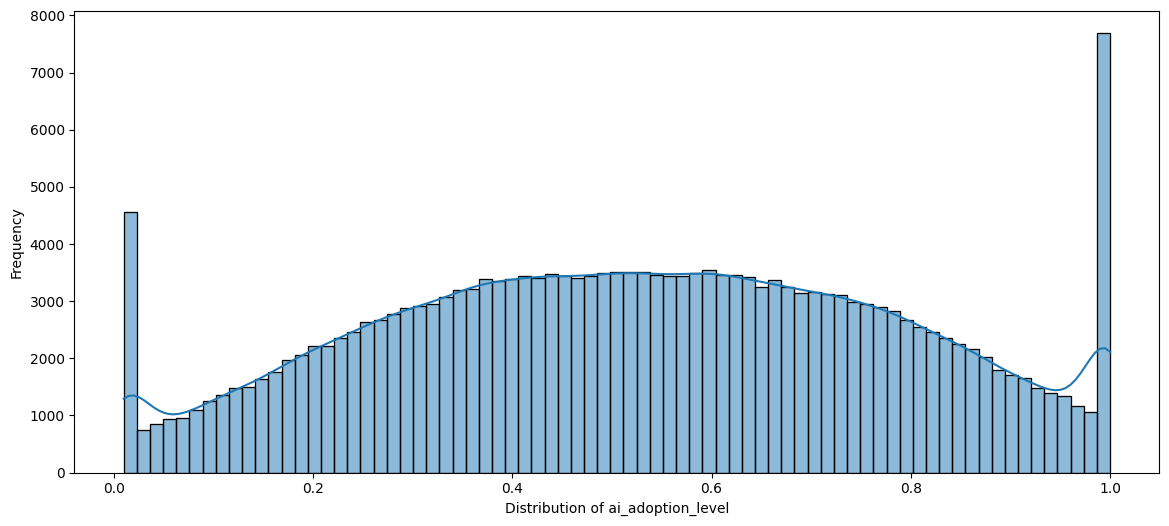

Mean: 0.5277742165
Median: 0.5286
Skewness: -0.040049306906802945


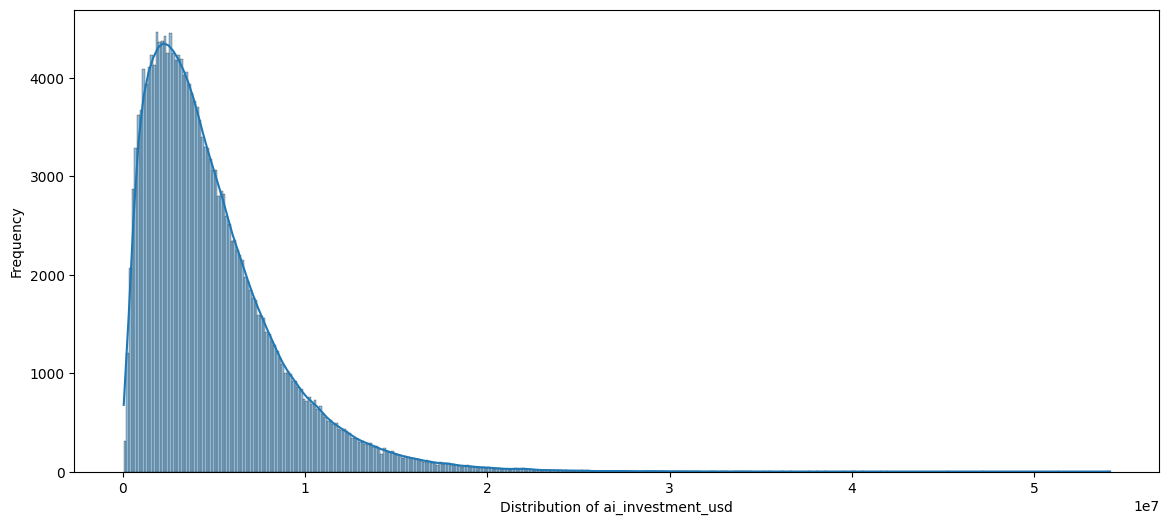

Mean: 4870558.43886
Median: 3991639.5
Skewness: 1.7025052196172883


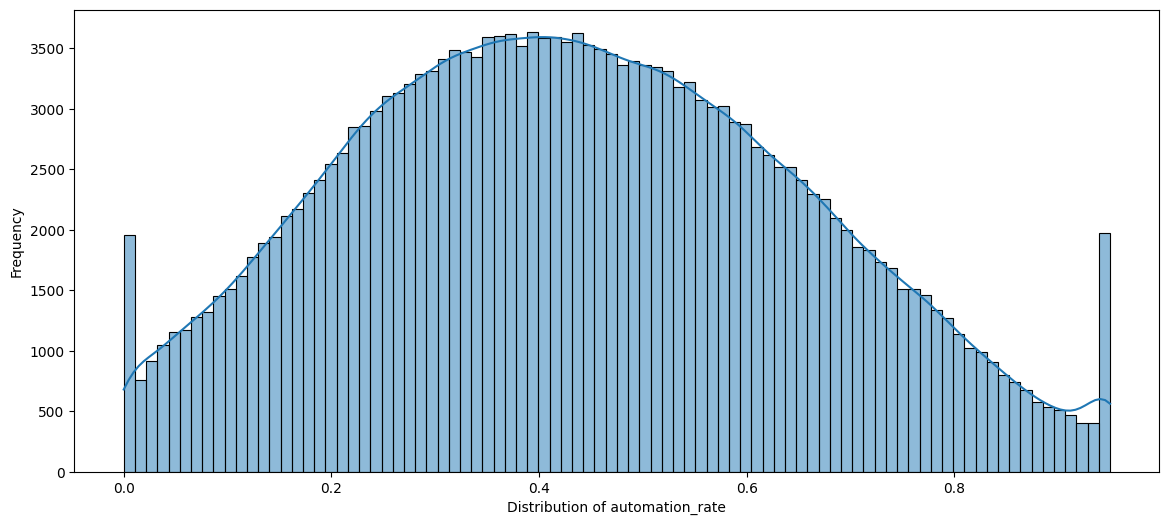

Mean: 0.4367225505
Median: 0.42815000000000003
Skewness: 0.16489538783863714


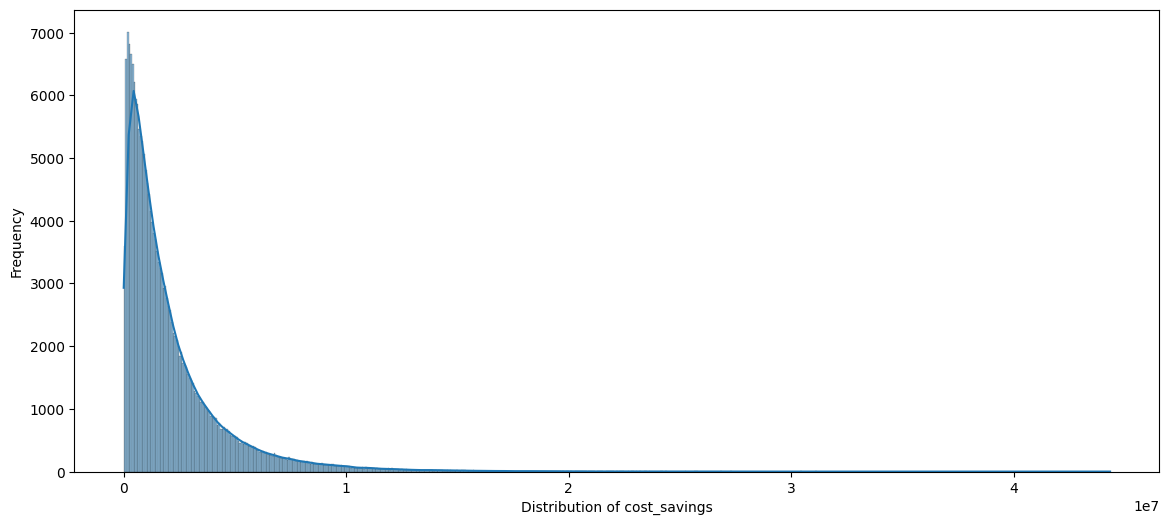

Mean: 2128917.872325
Median: 1354826.5
Skewness: 2.941821246770976


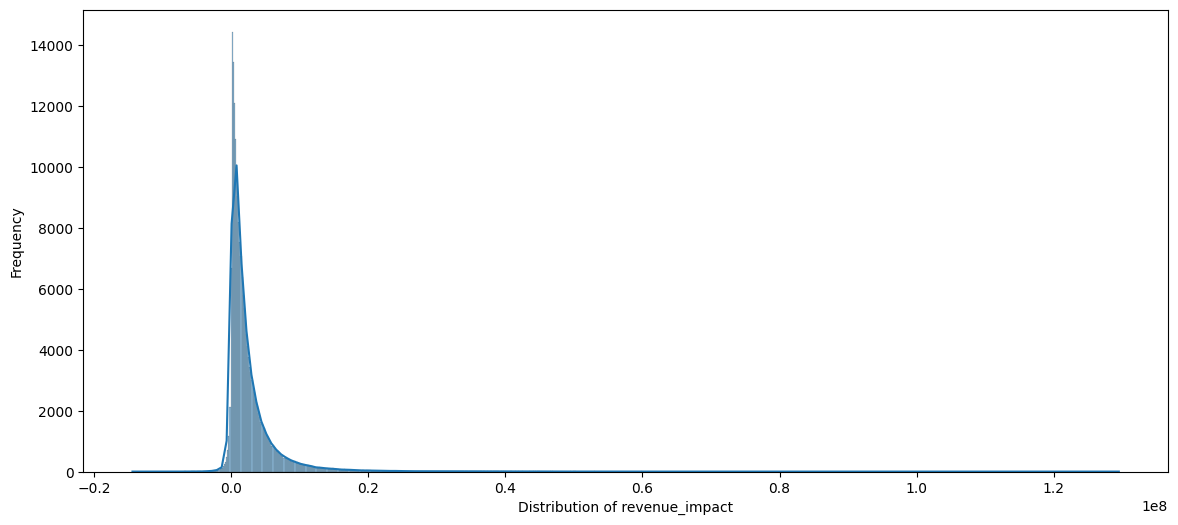

Mean: 2591989.184135
Median: 1408779.0
Skewness: 5.65932056504352


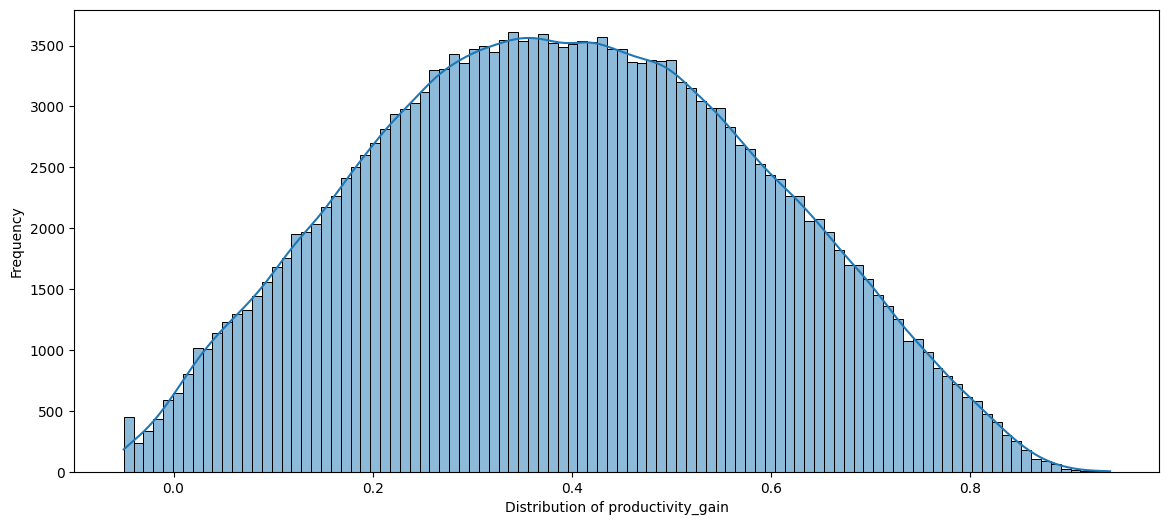

Mean: 0.395297029
Median: 0.3926
Skewness: 0.05106537067784202


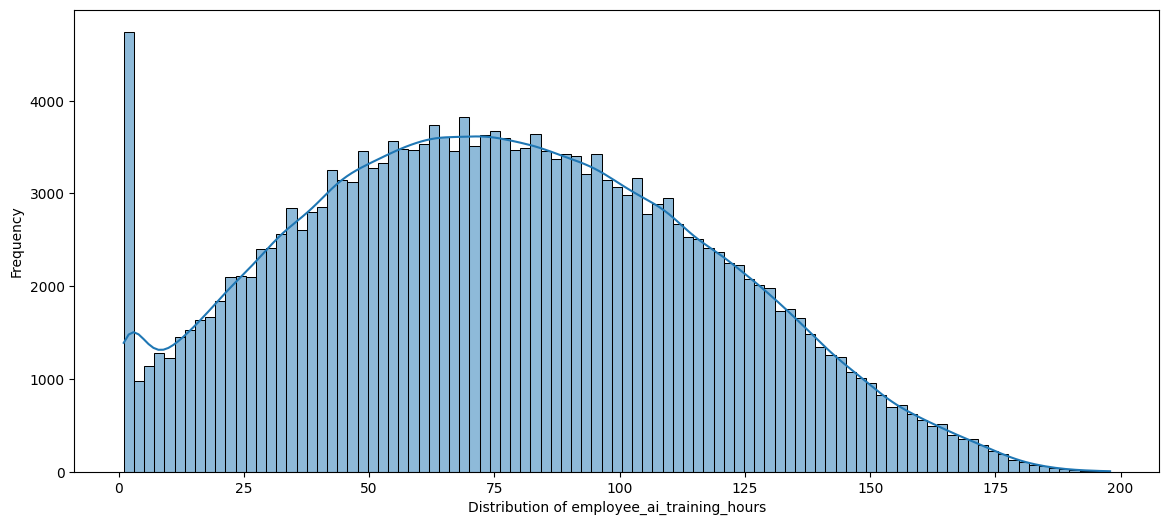

Mean: 76.755334
Median: 75.4
Skewness: 0.15565155508510142


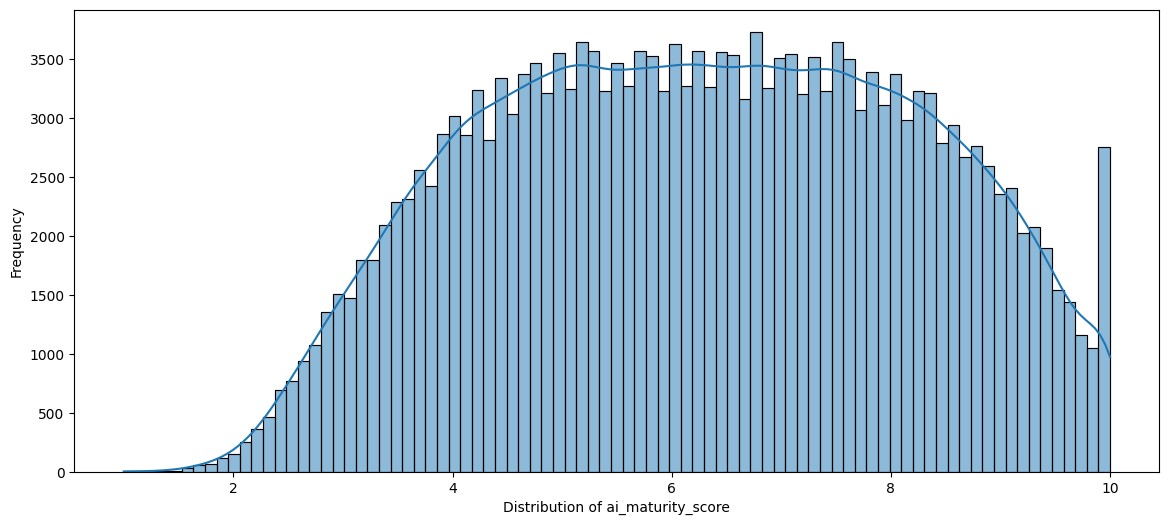

Mean: 6.271800699999999
Median: 6.28
Skewness: -0.029887571627255805


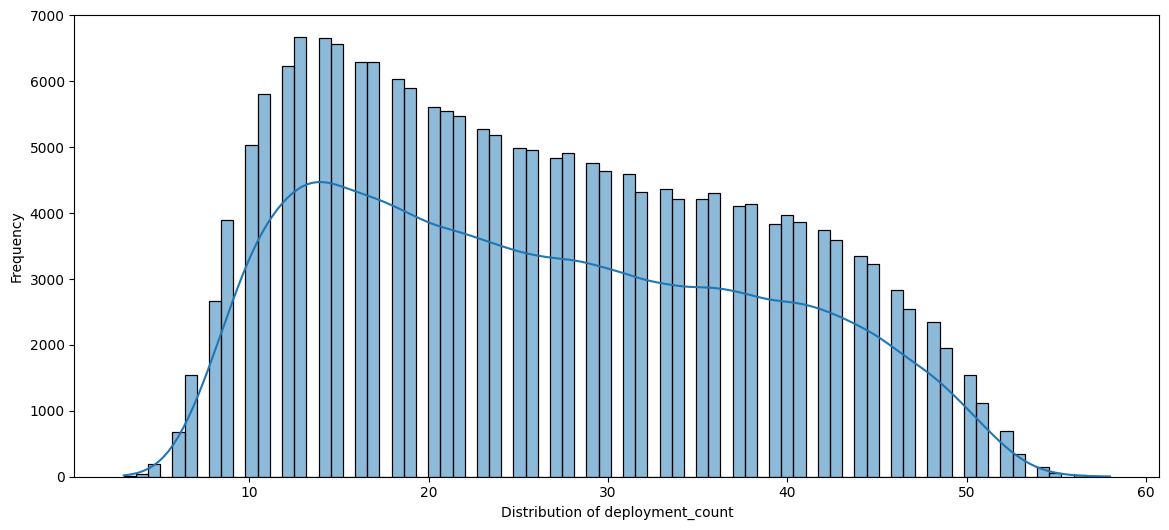

Mean: 26.33735
Median: 25.0
Skewness: 0.29454187646769836


In [21]:
# Univariate Analysis
numeric_cols = [
    'ai_adoption_level',
    'ai_investment_usd',
    'automation_rate',
    'cost_savings',
    'revenue_impact',
    'productivity_gain',
    'employee_ai_training_hours',
    'ai_maturity_score',
    'deployment_count'
]
for col in numeric_cols:
    plt.figure(figsize = (14, 6))

    sns.histplot(df[col], kde = True, legend = True)
    plt.xlabel(f"Distribution of {col}")
    plt.ylabel("Frequency")
    plt.show()

    print(f"Mean: {df[col].mean()}")
    print(f"Median: {df[col].median()}")
    print(f"Skewness: {df[col].skew()}")

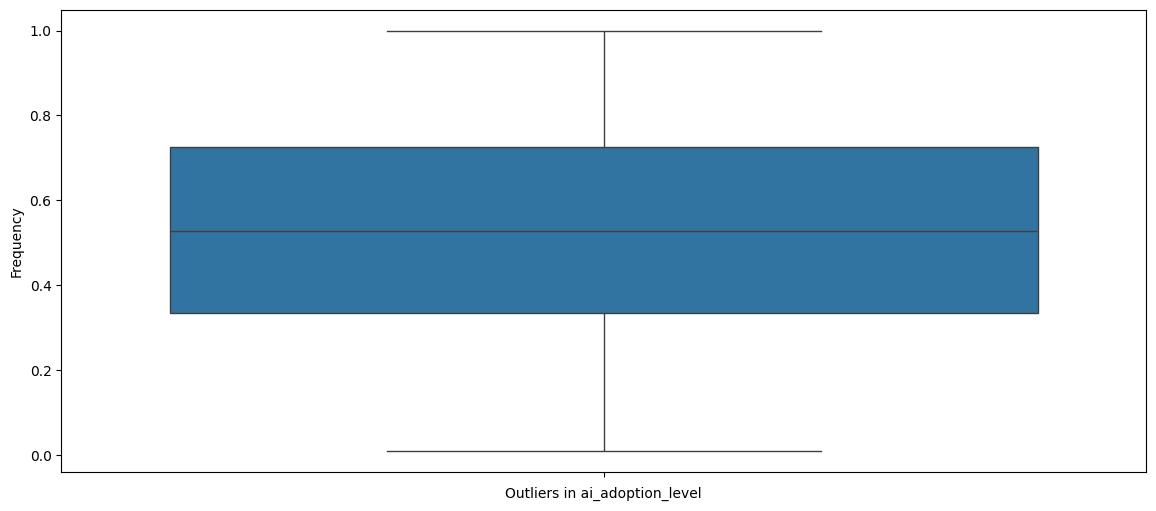

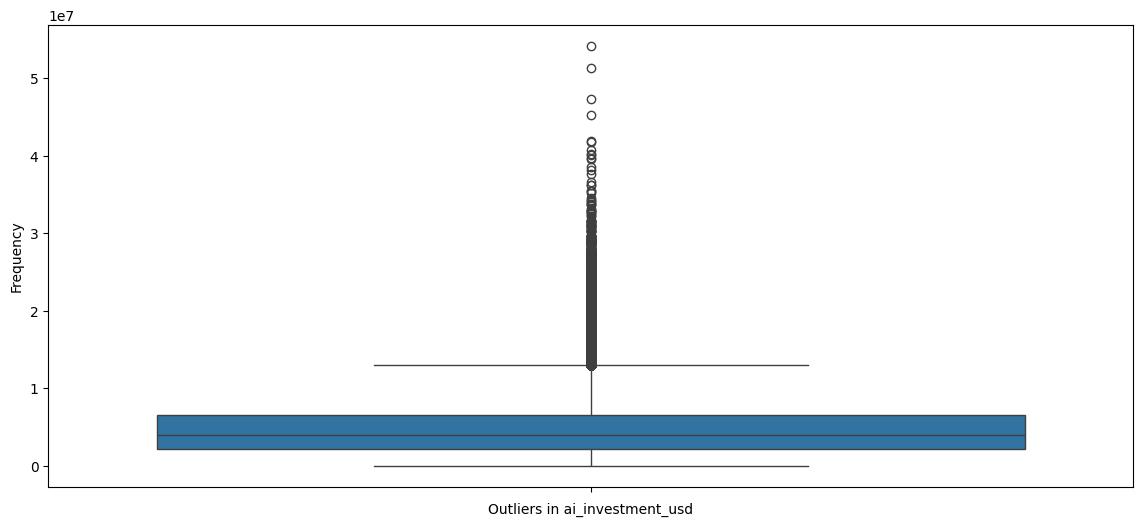

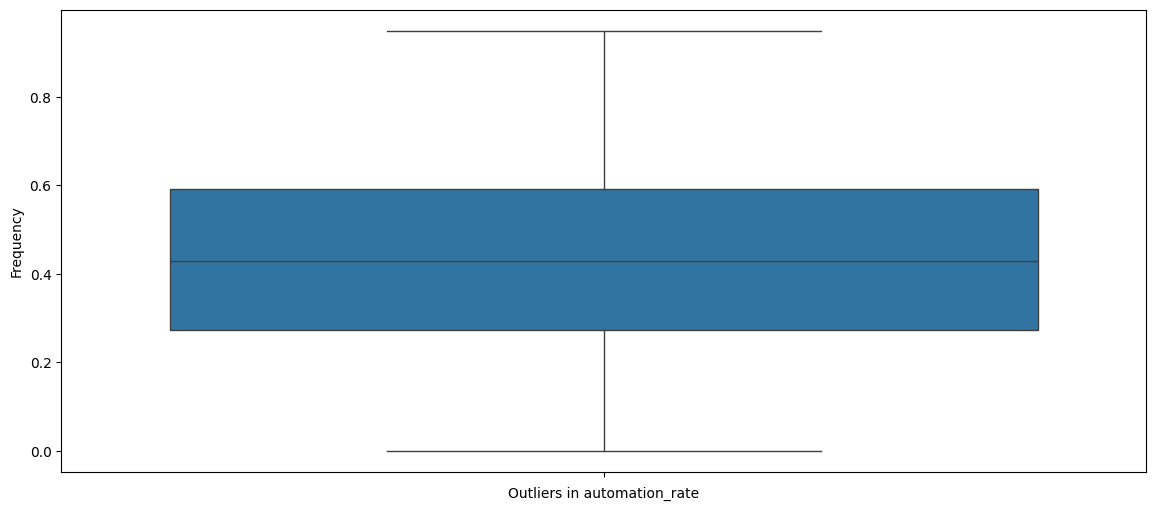

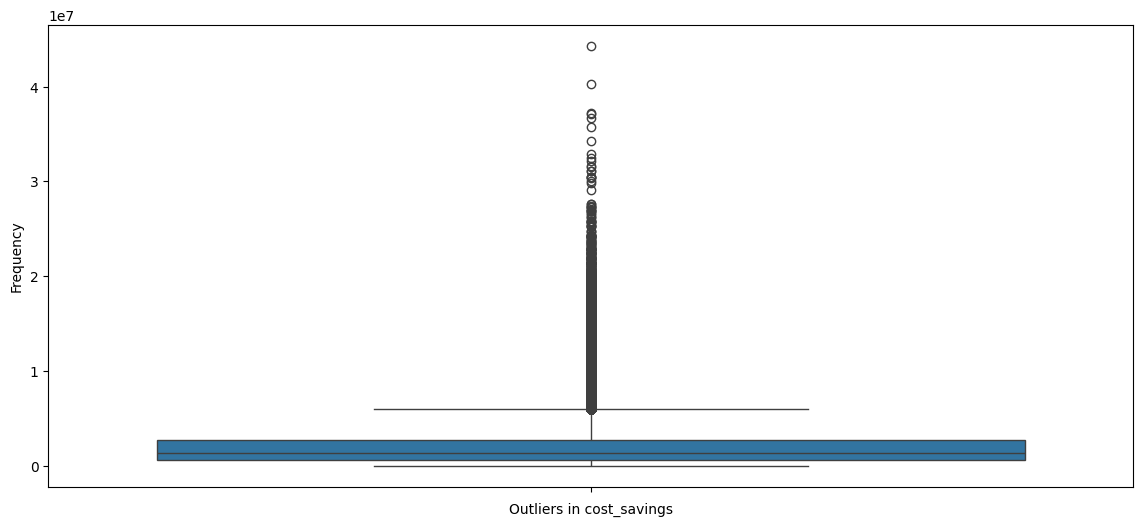

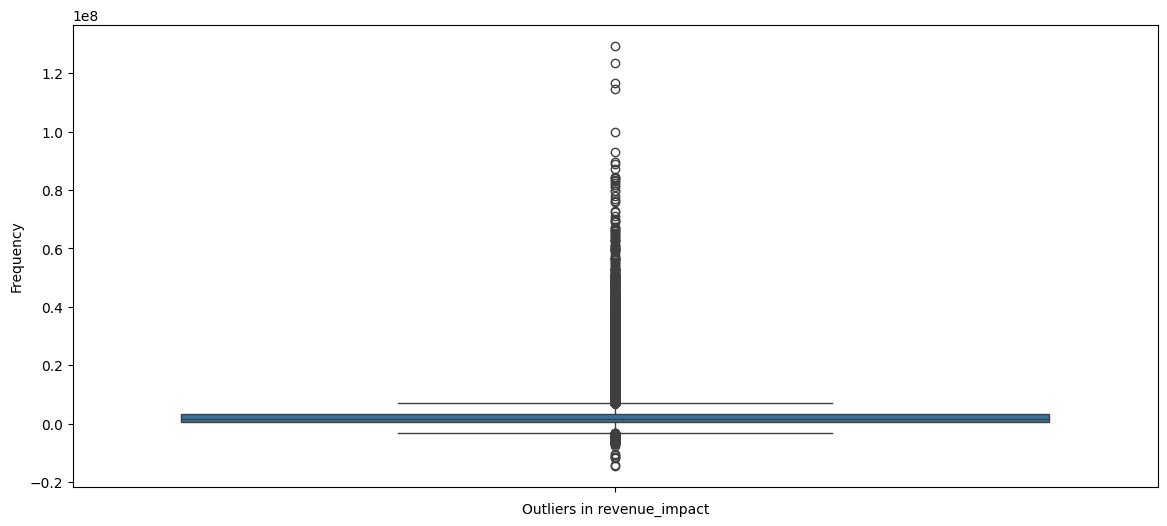

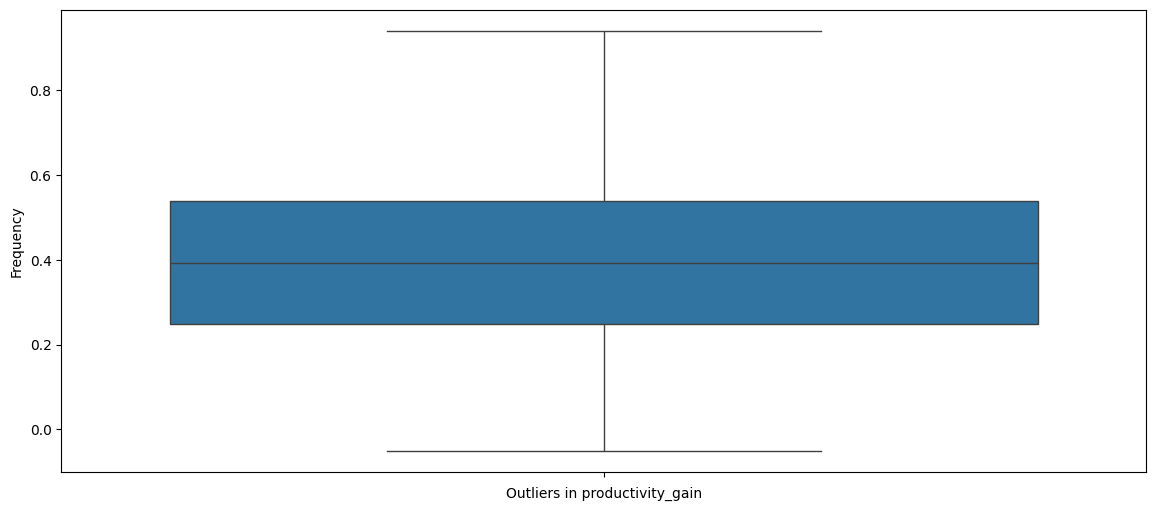

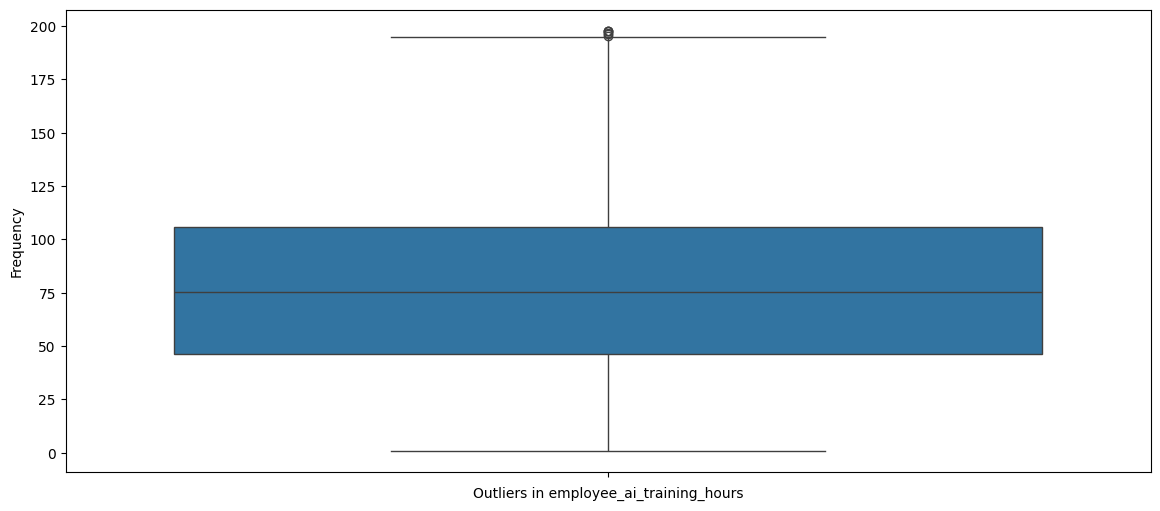

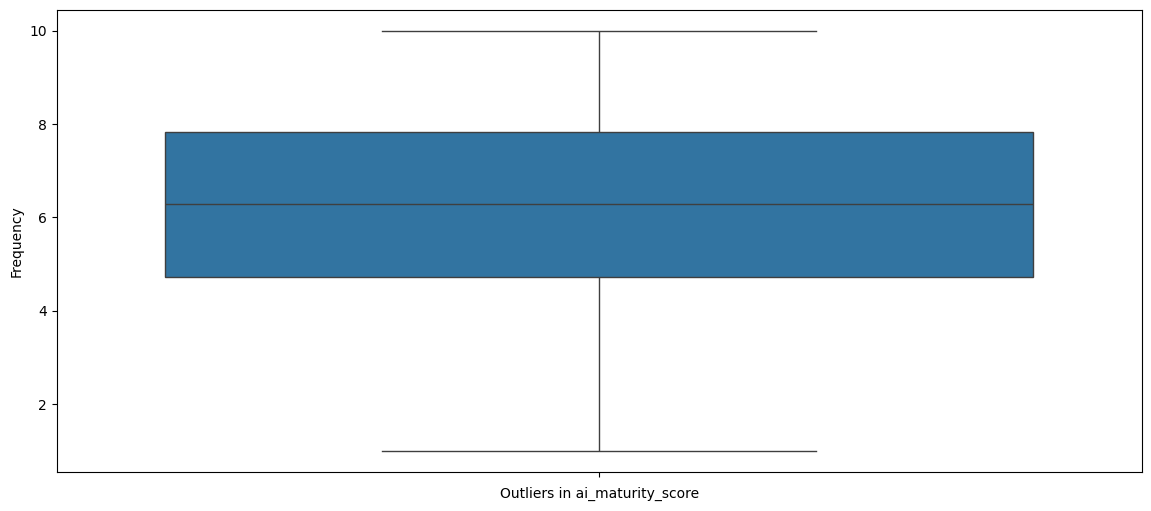

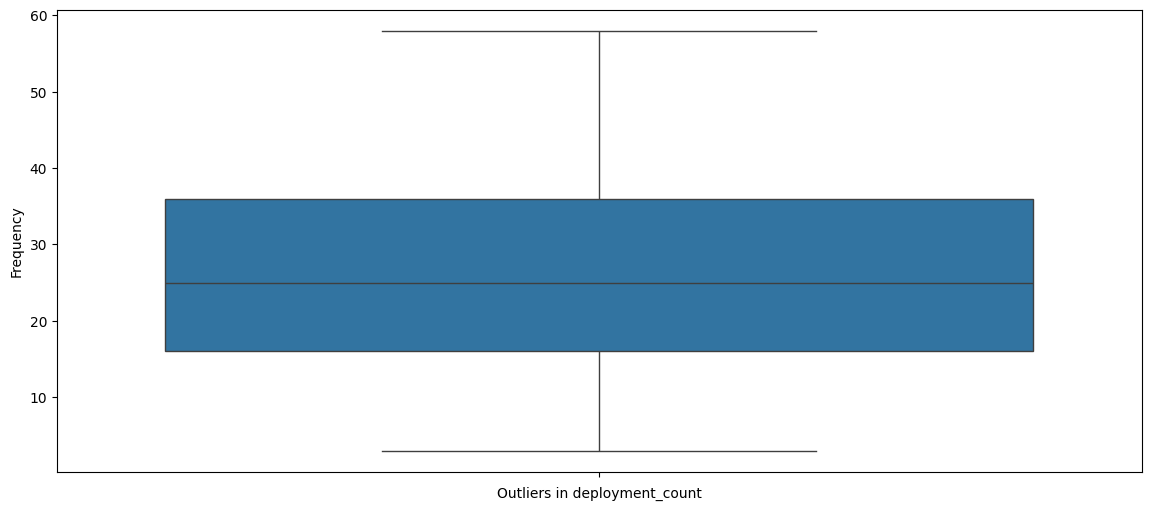

In [22]:
numeric_cols = [
    'ai_adoption_level',
    'ai_investment_usd',
    'automation_rate',
    'cost_savings',
    'revenue_impact',
    'productivity_gain',
    'employee_ai_training_hours',
    'ai_maturity_score',
    'deployment_count'
]
for col in numeric_cols:
    plt.figure(figsize = (14, 6))

    sns.boxplot(df[col])
    plt.xlabel(f"Outliers in {col}")
    plt.ylabel("Frequency")
    plt.show()


In [23]:
numeric_cols = [
    'ai_adoption_level',
    'ai_investment_usd',
    'automation_rate',
    'cost_savings',
    'revenue_impact',
    'productivity_gain',
    'employee_ai_training_hours',
    'ai_maturity_score',
    'deployment_count'
]

for cols in numeric_cols:
    Q1 = df[cols].quantile(0.25)
    Q3 = df[cols].quantile(0.75)

    IQR = Q3-Q1
    
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outlier = df[
    (df[cols] > upper) |
    (df[cols] < lower)
    ]
    pct = len(outlier) / len(df) * 100

    print(f"{cols}: {len(outlier)} outliers ({pct:.2f}%)")

ai_adoption_level: 0 outliers (0.00%)
ai_investment_usd: 7476 outliers (3.74%)
automation_rate: 0 outliers (0.00%)
cost_savings: 13386 outliers (6.69%)
revenue_impact: 15869 outliers (7.93%)
productivity_gain: 0 outliers (0.00%)
employee_ai_training_hours: 6 outliers (0.00%)
ai_maturity_score: 0 outliers (0.00%)
deployment_count: 0 outliers (0.00%)


In [24]:
industry_revenue_impact = df.groupby('industry')['revenue_impact'].mean().sort_values(ascending = False)
industry_revenue_impact

industry
Technology            5.527864e+06
Financial Services    3.863966e+06
Energy                2.267110e+06
Telecom               2.264975e+06
Healthcare            2.059374e+06
Manufacturing         1.476649e+06
Logistics             1.358749e+06
Retail                1.285910e+06
Agriculture           4.456794e+05
Education             2.533240e+05
Name: revenue_impact, dtype: float64

1. Which industry gains most productivity?
--> Manufacturing
2. Which industry spends most on AI?
--> Finance
3. Which industry generates most revenue?
--> Technology

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   company_id                  200000 non-null  object 
 1   industry                    200000 non-null  object 
 2   country                     200000 non-null  object 
 3   year                        200000 non-null  int64  
 4   ai_adoption_level           200000 non-null  float64
 5   ai_investment_usd           200000 non-null  int64  
 6   automation_rate             200000 non-null  float64
 7   cost_savings                200000 non-null  int64  
 8   revenue_impact              200000 non-null  int64  
 9   productivity_gain           200000 non-null  float64
 10  employee_ai_training_hours  200000 non-null  float64
 11  ai_maturity_score           200000 non-null  float64
 12  deployment_count            200000 non-null  int64  
dtypes: float64(5),

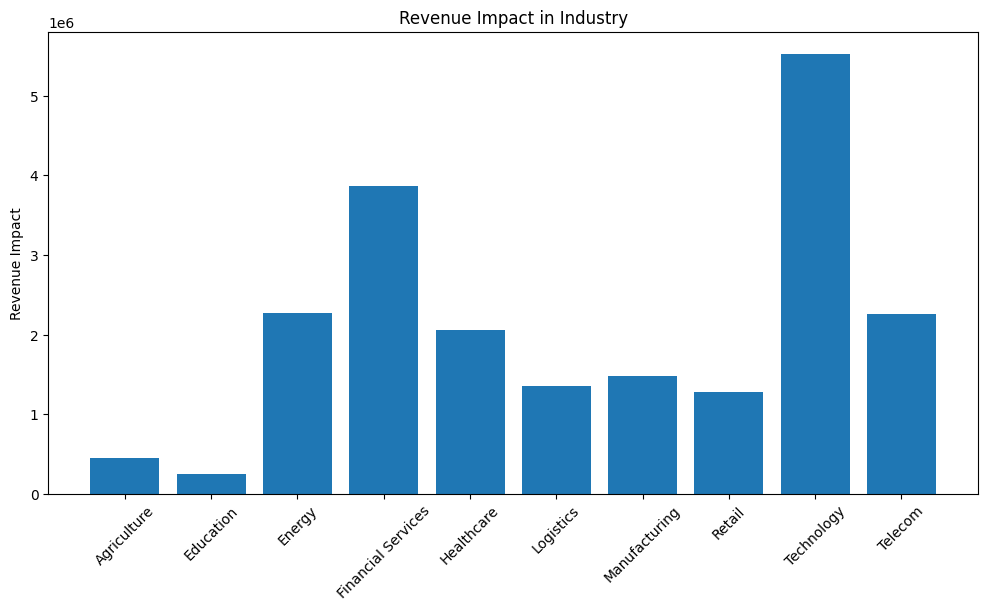

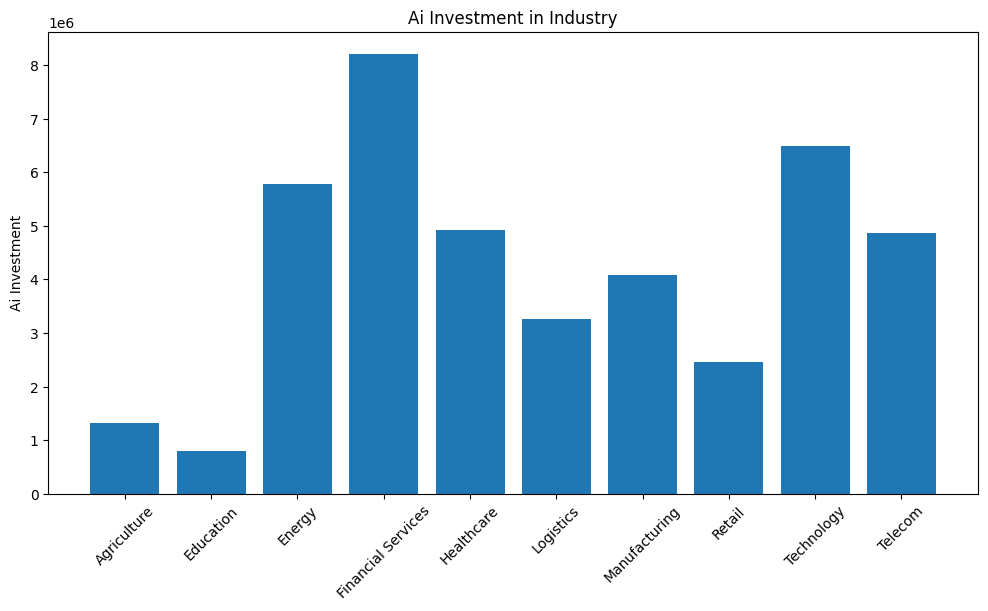

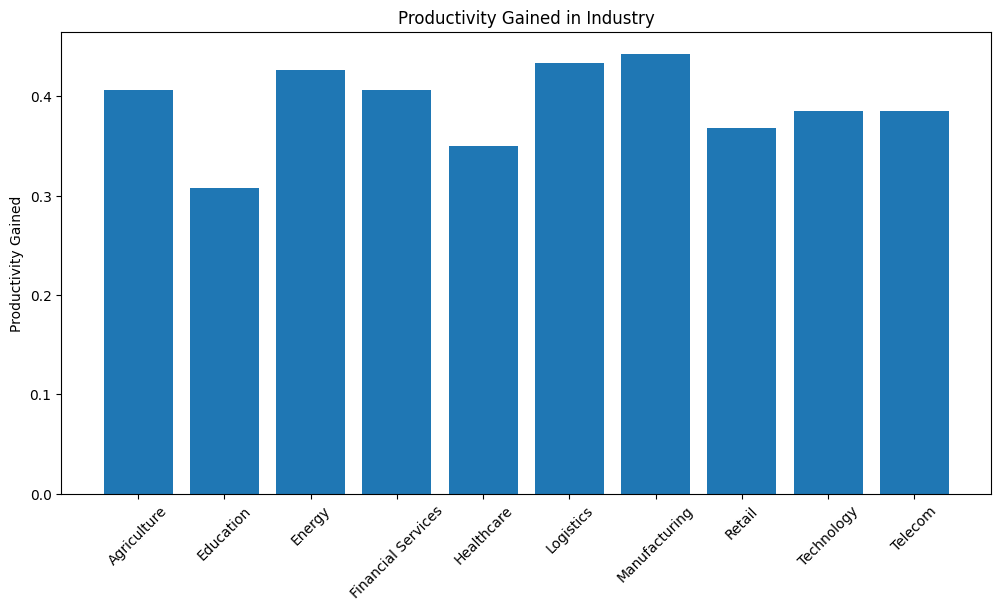

In [26]:
Cols = [
    'revenue_impact',
    'ai_investment_usd',
    'productivity_gain'
]

labels = [
    'Revenue Impact',
    'Ai Investment',
    'Productivity Gained'
]

def plot_industry_Cols(df, Cols, labels):
    data = df.groupby('industry')[Cols].mean()
    
    plt.figure(figsize=(12,6))
    plt.bar(data.index, data.values)
    plt.xticks(rotation=45)
    plt.ylabel(labels)
    plt.title(f'{labels} in Industry')
    plt.show()

for col, label in zip(Cols, labels):
    plot_industry_Cols(df, col, label)

In [27]:
df.head()

,company_id,industry,country,year,ai_adoption_level,ai_investment_usd,automation_rate,cost_savings,revenue_impact,productivity_gain,employee_ai_training_hours,ai_maturity_score,deployment_count
0,CORP-06613,Financial Services,China,2029,0.4987,11747237,0.4119,3519354,2751513,0.3924,76.8,6.37,29
1,CORP-01597,Agriculture,Germany,2032,0.5213,1267219,0.4580,295244,304776,0.4639,83.2,7.19,37
2,CORP-02938,Energy,United States,2024,0.6147,8168951,0.5821,2472329,5170304,0.4953,123.1,6.72,26
3,CORP-05207,Retail,Germany,2021,0.4401,1234261,0.2880,512061,-233448,0.3078,63.1,5.68,21
4,CORP-07489,Technology,United States,2024,0.1918,5000645,0.1906,2122064,2110644,0.1910,29.6,4.33,16


In [28]:
corr = df.corr(numeric_only = True)
corr['revenue_impact'].sort_values(ascending = False)

revenue_impact                1.000000
cost_savings                  0.702602
ai_investment_usd             0.673928
employee_ai_training_hours    0.439463
ai_adoption_level             0.434287
ai_maturity_score             0.416764
productivity_gain             0.414317
automation_rate               0.400922
deployment_count              0.399794
year                          0.343997
Name: revenue_impact, dtype: float64

In [6]:
df = df.drop('company_id', axis = 1)

df = pd.get_dummies(
    df,
    columns = ['industry', 'country'],
    drop_first = True
)

In [7]:
X = df.drop('revenue_impact', axis = 1)
y = df['revenue_impact']

In [8]:
# Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

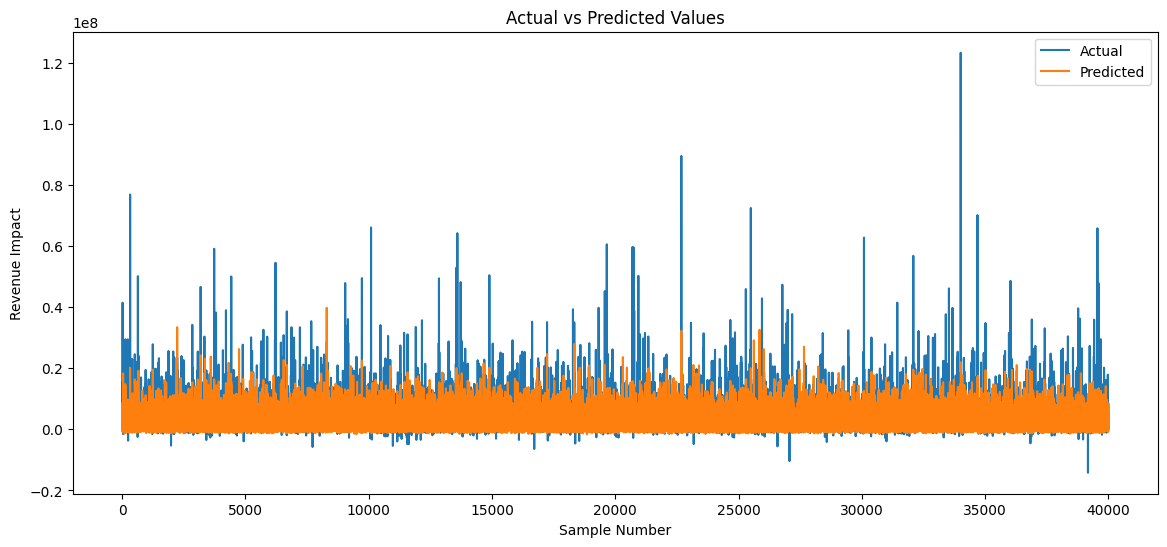

In [11]:
def plot_actual_predicted(Actual, predicted):
    comparison = pd.DataFrame({
        'Actual': Actual.values,
        'Predicted': predicted
    })
    
    comparison = comparison.reset_index(drop=True)
    
    plt.figure(figsize=(14,6))
    
    plt.plot(comparison['Actual'], label='Actual')
    plt.plot(comparison['Predicted'], label='Predicted')
    
    plt.title('Actual vs Predicted Values')
    plt.xlabel('Sample Number')
    plt.ylabel('Revenue Impact')
    plt.legend()
    
    plt.show()

plot_actual_predicted(y_test, y_pred_lr)

In [12]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


def evaluation_metrics(y_test, y_predict):
    mae = mean_absolute_error(y_test, y_predict)
    mse = mean_squared_error(y_test, y_predict)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_predict)

    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")

    return mae, mse, rmse, r2

evaluation_metrics(y_test, y_pred_lr)

MAE  : 1243477.29
MSE  : 6675013483876.19
RMSE : 2583604.75
R²   : 0.5493


(1243477.2880363038,
 6675013483876.1875,
 2583604.7460624054,
 0.5493129805207728)

In [88]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 5)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

model_lr_pca = LinearRegression()
model_lr_pca.fit(X_train, y_train)

y_pred_lr_pca = model_lr_pca.predict(X_test)

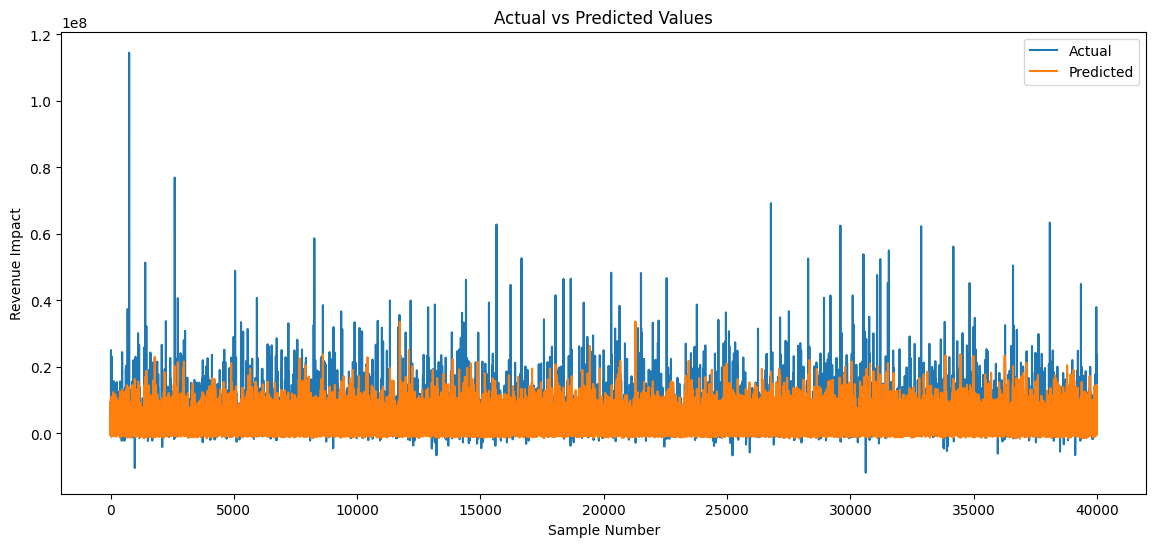

MAE  : 1257939.28
MSE  : 6677563189441.05
RMSE : 2584098.14
R²   : 0.5531


In [91]:
plot_actual_predicted(y_test, y_pred_lr_pca)
evaluation_metrics(y_test, y_pred_lr_pca)

In [95]:
from sklearn.ensemble import RandomForestRegressor

model_rfr = RandomForestRegressor()
model_rfr.fit(X_train, y_train)

y_predict_rfr = model_rfr.predict(X_test)

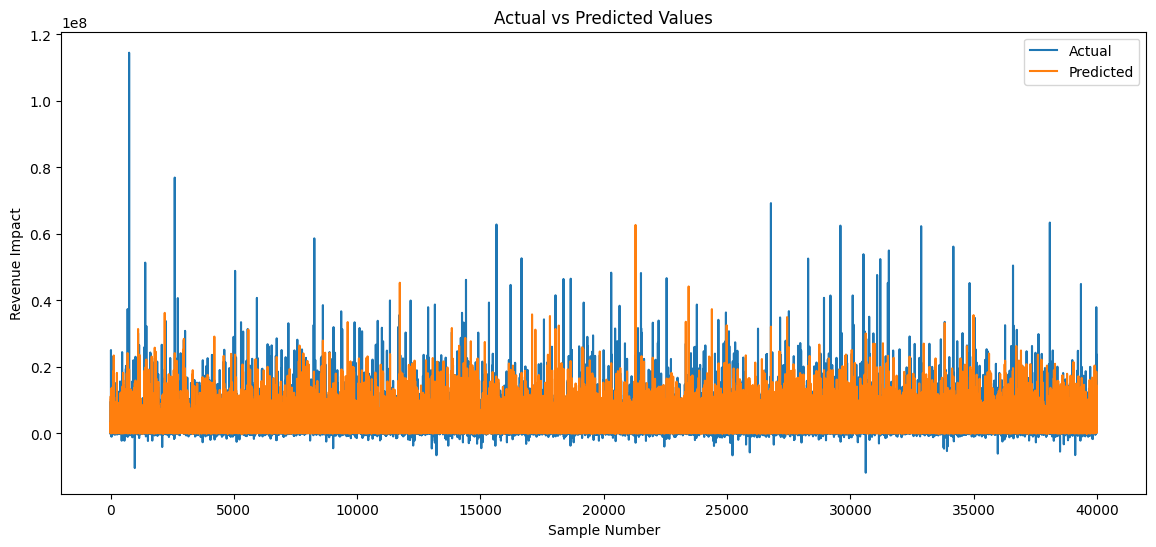

MAE  : 1096464.05
MSE  : 6520058216669.44
RMSE : 2553440.47
R²   : 0.5636


(1096464.0514915, 6520058216669.443, 2553440.4666389707, 0.5636119824584565)

In [96]:
plot_actual_predicted(y_test, y_predict_rfr)
evaluation_metrics(y_test, y_predict_rfr)

In [15]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor()
model_gb.fit(X_train, y_train)

y_predict_gb = model_gb.predict(X_test)

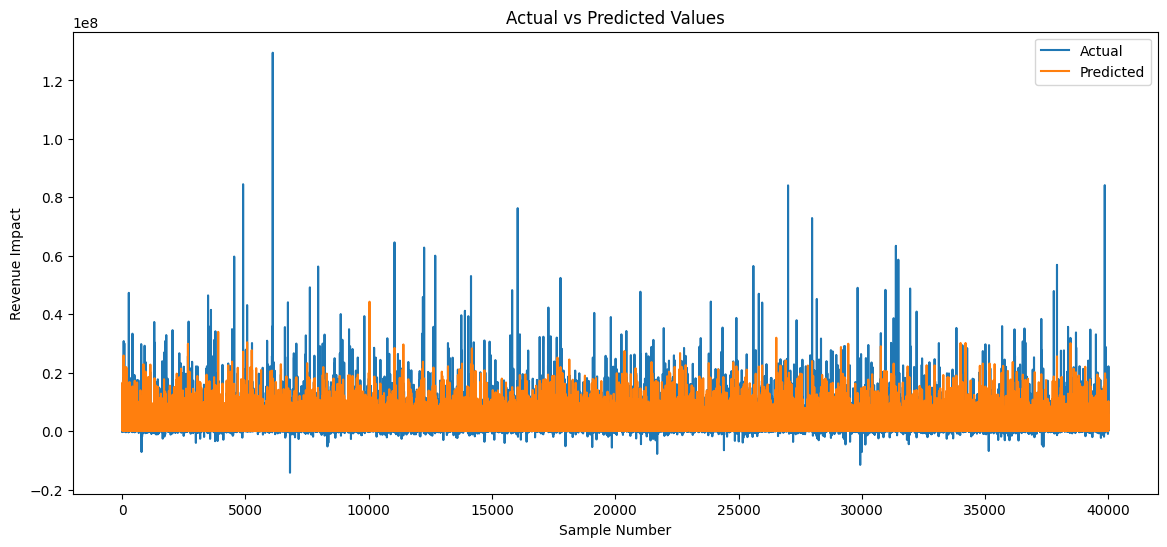

MAE  : 1083180.51
MSE  : 6562323527539.31
RMSE : 2561703.25
R²   : 0.5860


(1083180.5053343356, 6562323527539.312, 2561703.2473608865, 0.5859803601561573)

In [21]:
plot_actual_predicted(y_test, y_predict_gb)
evaluation_metrics(y_test, y_predict_gb)

In [15]:
import xgboost as xgb

model_xgb = xgb.XGBRegressor()
model_xgb.fit(X_train, y_train)

y_predict_xgb = model_xgb.predict(X_test)

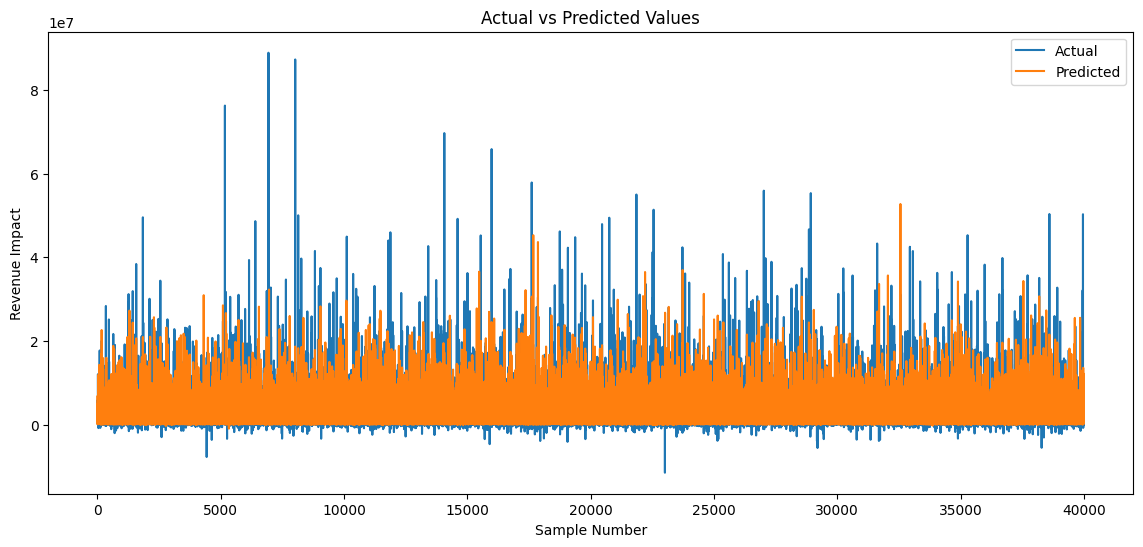

MAE  : 1086309.25
MSE  : 6606369062912.00
RMSE : 2570285.79
R²   : 0.5649


(1086309.25, 6606369062912.0, 2570285.7940143542, 0.5648593902587891)

In [16]:
plot_actual_predicted(y_test, y_predict_xgb)
evaluation_metrics(y_test, y_predict_xgb)

# HPO

In [16]:
lr = LinearRegression()
lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
from sklearn.model_selection import RandomizedSearchCV

lr = LinearRegression()

param_dist_lr = {
    'fit_intercept' : [True, False]
}

random_lr = RandomizedSearchCV(
    estimator = lr,
    param_distributions = param_dist_lr,
    n_iter = 2,
    cv = 5,
    scoring = 'r2',
    random_state = 42,
    n_jobs = -1
)

random_lr.fit(X_train, y_train)

y_pred_random_lr = random_lr.predict(X_test)

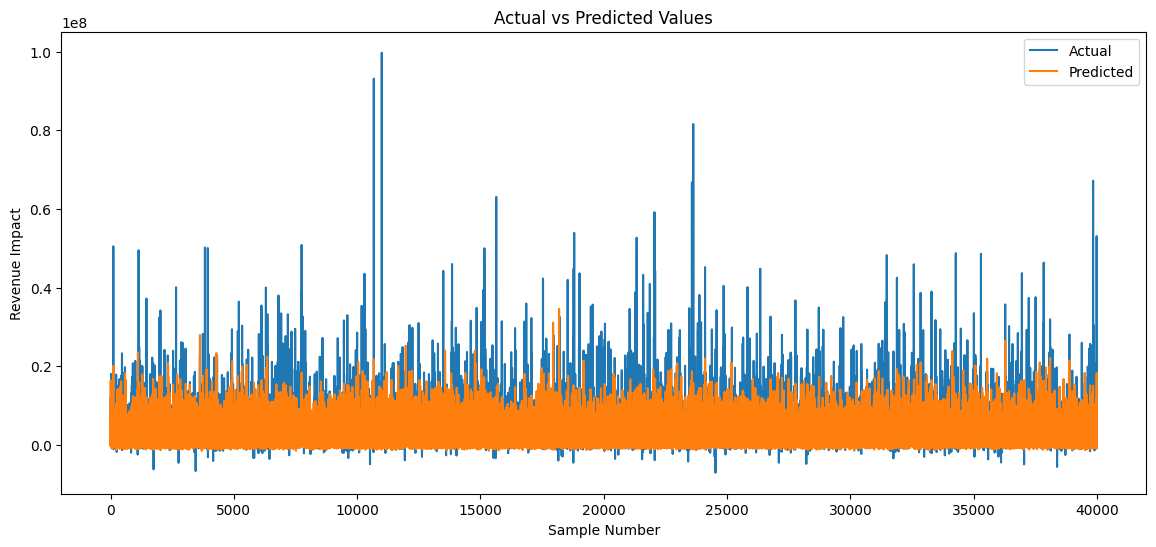

MAE  : 1253075.36
MSE  : 6647162863887.49
RMSE : 2578209.24
R²   : 0.5625


(1253075.356218969, 6647162863887.486, 2578209.2358626532, 0.5625363731006374)

In [21]:
plot_actual_predicted(y_test, y_pred_random_lr)
evaluation_metrics(y_test, y_pred_random_lr)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)

params_dist_gbr = {
    'n_estimators' : [100, 200, 300, 500],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'max_depth' : [3, 4, 5, 6],
    'subsample' : [0.7, 0.8, 0.9, 1.0],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

random_gbr = RandomizedSearchCV(
    estimator = gbr,
    param_distributions = params_dist_gbr,
    n_iter = 30,
    cv = 5,
    scoring = 'r2',
    random_state = 42,
    n_jobs = -1
)

random_gbr.fit(X_train, y_train)

y_pred_random_gbr = random_gbr.predict(X_test)

In [ ]:
plot_actual_predicted(y_test, y_pred_random_gbr)
evaluation_metrics(y_test, y_pred_random_gbr)

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42,
    objective='reg:squarederror'
)

param_dist_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3, 0.5]
}

random_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_xgb.fit(X_train, y_train)
y_pred_random_Xgb = random_xgb.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(
    random_state=42
)

param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

random_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_rf.fit(X_train, y_train)
y_pred_random_Xgb = random_xgb.predict(X_test)

print("Best Parameters:")
print(random_rf.best_params_)

print("\nBest CV R² Score:")
print(random_rf.best_score_)